In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

ANGSTROM_TO_BOHR = 1.8897259886
AU_TO_DEBYE = 2.541746
HARTREE_TO_EV = 27.211386

coords = np.loadtxt("geometry.txt", usecols=(1, 2, 3)) * ANGSTROM_TO_BOHR
partial_charges = np.loadtxt("partial_charges.txt", usecols=(1))

In [11]:
dipole_moment = np.sum(partial_charges[:, np.newaxis] * coords, axis=0) * AU_TO_DEBYE
print(f"Dipole moment (Debye): {dipole_moment}")

Dipole moment (Debye): [-0.02763955  0.19518922  0.55560096]


In [12]:
total_energy = 0.0

for i in range(coords.shape[0]):
    for j in range(coords.shape[0]):
        if i != j:
            r_ij = np.linalg.norm(coords[i] - coords[j])
            interaction_energy = partial_charges[i] * partial_charges[j] / r_ij
            total_energy += interaction_energy

total_energy *= 1/2 * HARTREE_TO_EV
print(f"Total electrostatic energy (eV): {total_energy}")

Total electrostatic energy (eV): -17.798135449765407


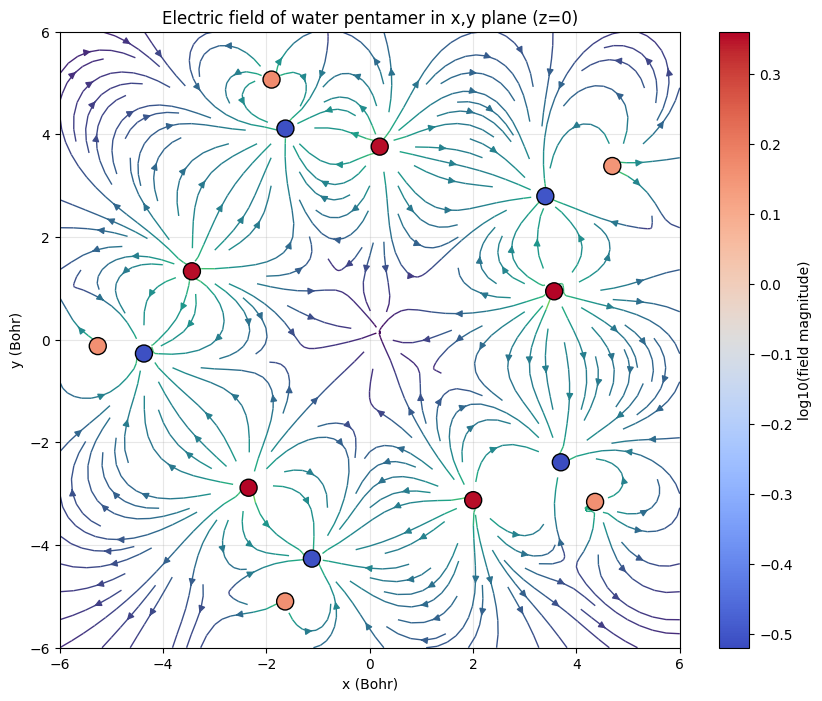

In [18]:
axis = np.linspace(-6.0, 6.0, 60)
X, Y = np.meshgrid(axis, axis)

Ex = np.zeros_like(X)
Ey = np.zeros_like(Y)

for i in range(coords.shape[0]):
    r = np.sqrt((X - coords[i, 0])**2 + (Y - coords[i, 1])**2)
    Ex += partial_charges[i] * (X - coords[i, 0]) / r**3
    Ey += partial_charges[i] * (Y - coords[i, 1]) / r**3

plt.figure(figsize=(10, 8))

E_magnitude = np.sqrt(Ex**2 + Ey**2)
stream = plt.streamplot(X, Y, Ex, Ey, color=np.log10(E_magnitude + 1e-9), 
                        cmap='viridis', density=1.5, linewidth=1)

plt.scatter(coords[:, 0], coords[:, 1], c=partial_charges, 
            cmap='coolwarm', s=150, edgecolor='black', zorder=5)

plt.colorbar(label='log10(field magnitude)')
plt.title('Electric field of water pentamer in x,y plane (z=0)')
plt.xlabel('x (Bohr)')
plt.ylabel('y (Bohr)')
plt.xlim(-6, 6)
plt.ylim(-6, 6)
plt.grid(True, alpha=0.3)
plt.show()

In [23]:
R = 8.0

def get_E_field_at_point(x, y, z, coords, partial_charges):
    Ex = Ey = Ez = 0.0
    for i in range(coords.shape[0]):
        r = np.sqrt((x - coords[i, 0])**2 + (y - coords[i, 1])**2 + (z - coords[i, 2])**2)  # ← 3D!
        Ex += partial_charges[i] * (x - coords[i, 0]) / r**3
        Ey += partial_charges[i] * (y - coords[i, 1]) / r**3
        Ez += partial_charges[i] * (z - coords[i, 2]) / r**3
    return np.array([Ex, Ey, Ez])

def integrand(theta):
    x = R * np.cos(theta)
    y = R * np.sin(theta)
    z = 0.0

    E_field = get_E_field_at_point(x, y, z, coords, partial_charges)
    dl = R * np.array([-np.sin(theta), np.cos(theta), 0.0])

    return np.dot(E_field, dl) * HARTREE_TO_EV

work_done, _ = quad(integrand, 0, 2 * np.pi)

print(f'Work done by electric field around closed loop: {work_done:.4e} eV')
print(f'Estimated numerical error: {_:.4e} eV')

Work done by electric field around closed loop: 2.6645e-15 eV
Estimated numerical error: 1.2145e-08 eV
